In [2]:
%pip install tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\TY-Dl-codes\spam(3).csv", encoding="latin-1")

# Keep only required columns
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print(df.head())
print("\nDataset Shape:", df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset Shape: (5572, 2)


In [5]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print(df["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [6]:
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

tokenizer.fit_on_texts(df["message"])
sequences = tokenizer.texts_to_sequences(df["message"])

print("Sample Sequence:", sequences[0])

Sample Sequence: [51, 470, 4411, 842, 752, 658, 65, 9, 1325, 90, 122, 350, 1326, 148, 2988, 1327, 68, 59, 4412, 145]


In [7]:
max_length = 100
X = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

y = df["label"].values

print("Padded Shape:", X.shape)

Padded Shape: (5572, 100)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (4457, 100)
Test Shape: (1115, 100)


In [9]:
fnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [10]:
rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    SimpleRNN(64),
    Dense(1, activation="sigmoid")
])

In [11]:
fnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("FNN Model Summary:")
fnn_model.summary()

print("\nRNN Model Summary:")
rnn_model.summary()

FNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
start_fnn = time.time()

history_fnn = fnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

end_fnn = time.time()
fnn_train_time = end_fnn - start_fnn

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8603 - loss: 0.3866 - val_accuracy: 0.8621 - val_loss: 0.3715
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8670 - loss: 0.3573 - val_accuracy: 0.8621 - val_loss: 0.3603
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8670 - loss: 0.3387 - val_accuracy: 0.8621 - val_loss: 0.3329
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8712 - loss: 0.2746 - val_accuracy: 0.8991 - val_loss: 0.2098
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9543 - loss: 0.1381 - val_accuracy: 0.9720 - val_loss: 0.1013
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9787 - loss: 0.0732 - val_accuracy: 0.9765 - val_loss: 0.0758
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9826 - loss: 0.0572 - val_accuracy: 0.9753 - val_loss: 0.0750
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9874 - loss: 0.0452 - val_accuracy: 0

In [13]:
start_rnn = time.time()

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

end_rnn = time.time()
rnn_train_time = end_rnn - start_rnn

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8637 - loss: 0.4033 - val_accuracy: 0.8621 - val_loss: 0.4019
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8670 - loss: 0.3938 - val_accuracy: 0.8621 - val_loss: 0.4013
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8670 - loss: 0.3939 - val_accuracy: 0.8621 - val_loss: 0.4056
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8670 - loss: 0.3937 - val_accuracy: 0.8621 - val_loss: 0.4090
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8670 - loss: 0.3949 - val_accuracy: 0.8621 - val_loss: 0.4027
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8670 - loss: 0.3937 - val_accuracy: 0.8621 - val_loss: 0.4033
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8670 - loss: 0.3942 - val_accuracy: 0.8621 - val_loss: 0.4012
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8670 - loss: 0.3935 - val_accu

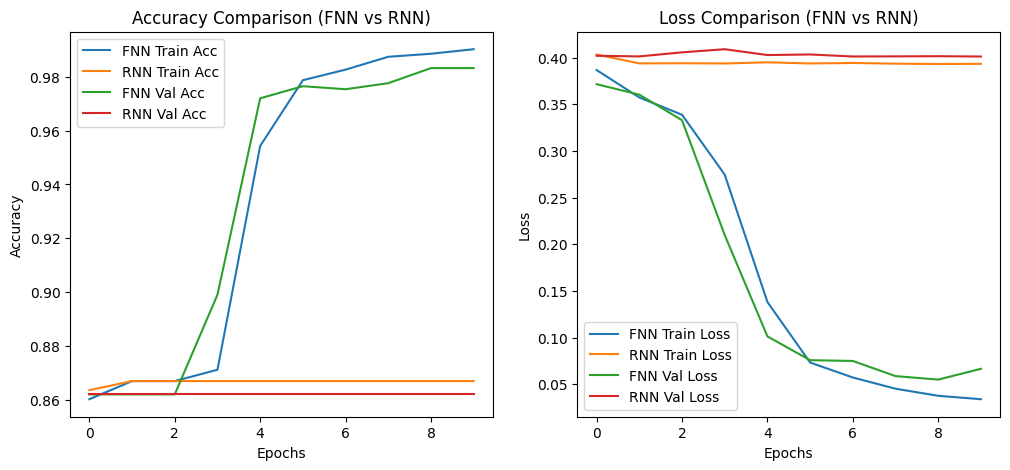

In [14]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history_fnn.history["accuracy"], label="FNN Train Acc")
plt.plot(history_rnn.history["accuracy"], label="RNN Train Acc")
plt.plot(history_fnn.history["val_accuracy"], label="FNN Val Acc")
plt.plot(history_rnn.history["val_accuracy"], label="RNN Val Acc")
plt.title("Accuracy Comparison (FNN vs RNN)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_fnn.history["loss"], label="FNN Train Loss")
plt.plot(history_rnn.history["loss"], label="RNN Train Loss")
plt.plot(history_fnn.history["val_loss"], label="FNN Val Loss")
plt.plot(history_rnn.history["val_loss"], label="RNN Val Loss")
plt.title("Loss Comparison (FNN vs RNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
# FNN Evaluation
fnn_loss, fnn_acc = fnn_model.evaluate(X_test, y_test, verbose=0)

# RNN Evaluation
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)

print("FNN Test Accuracy:", round(fnn_acc * 100, 2), "%")
print("RNN Test Accuracy:", round(rnn_acc * 100, 2), "%")

FNN Test Accuracy: 98.03 %
RNN Test Accuracy: 86.55 %


In [16]:
# FNN Inference Time
start = time.time()
fnn_preds = fnn_model.predict(X_test)
fnn_infer_time = time.time() - start

# RNN Inference Time
start = time.time()
rnn_preds = rnn_model.predict(X_test)
rnn_infer_time = time.time() - start

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [17]:
comparison = pd.DataFrame({
    "Model": ["FNN (Feedforward)", "RNN (SimpleRNN)"],
    "Test Accuracy": [fnn_acc, rnn_acc],
    "Test Loss": [fnn_loss, rnn_loss],
    "Inference Time (sec)": [fnn_infer_time, rnn_infer_time]
})

comparison

,Model,Test Accuracy,Test Loss,Inference Time (sec)
0,FNN (Feedforward),0.980269,0.083439,0.287525
1,RNN (SimpleRNN),0.865471,0.394919,0.694366


In [18]:
sample_messages = df["message"].iloc[:5].values
sample_seq = tokenizer.texts_to_sequences(sample_messages)
sample_pad = pad_sequences(sample_seq, maxlen=max_length, padding="post")

fnn_sample_preds = (fnn_model.predict(sample_pad) > 0.5).astype(int)
rnn_sample_preds = (rnn_model.predict(sample_pad) > 0.5).astype(int)

print("Sample Predictions (FNN vs RNN):\n")
for i in range(5):
    print("Message:", sample_messages[i])
    print("FNN Prediction:", fnn_sample_preds[i][0], 
          "| RNN Prediction:", rnn_sample_preds[i][0])
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Sample Predictions (FNN vs RNN):

Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
FNN Prediction: 0 | RNN Prediction: 0
------------------------------------------------------------
Message: Ok lar... Joking wif u oni...
FNN Prediction: 0 | RNN Prediction: 0
------------------------------------------------------------
Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
FNN Prediction: 1 | RNN Prediction: 0
------------------------------------------------------------
Message: U dun say so early hor... U c already then say...
FNN Prediction: 0 | RNN Prediction: 0
------------------------------------------------------------
Message: Nah I don't think he goes to usf, he lives around here though
FNN Prediction: 0 | RNN Prediction: 0
-